<a href="https://colab.research.google.com/github/MarioPEL58/Finance/blob/main/Frontiera_Efficiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# See which indexes are available here: https://github.com/paolocole/Stock-Indexes-Historical-Data/tree/main/DAILY/NET

url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/"

msci_indexes = [
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/USA.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/GERMANY.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/ITALY.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SWITZERLAND.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/UNITED-KINGDOM.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/JAPAN.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/SPAIN.csv",
    "DAILY/NET/EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/EUROPE.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/EM-EMERGING-MARKETS.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/CHINA.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/INDIA.csv",
    "DAILY/NET/EUR/EMERGING-MARKETS-EM/Country/NONE/NONE/STANDARD-LARGE-MID-CAP/MEXICO.csv",
    "DAILY/NET/EUR/EXTRA/GOLD.csv"]

In [26]:
import pandas as pd
import os

def load_msci_data(base_url, paths):
    all_dfs = []
    for path in paths:
        # Construct full URL
        full_url = base_url + path

        # Extract a clean name from the filename (e.g., 'WORLD', 'USA')
        name = os.path.basename(path).replace('.csv', '')

        # Read the CSV: first row header, first col date, second col price
        df = pd.read_csv(full_url, usecols=[0, 1], names=['Date', name], header=0, parse_dates=['Date'])

        # Set Date as index
        df.set_index('Date', inplace=True)
        all_dfs.append(df)

    # Join all dataframes on the Date index
    combined_df = pd.concat(all_dfs, axis=1)
    return combined_df.sort_index()

# Execute the download and merging
merged_df = load_msci_data(url, msci_indexes)

# Display the first few rows
display(merged_df.head())

,WORLD,USA,GERMANY,ITALY,SWITZERLAND,UNITED-KINGDOM,JAPAN,SPAIN,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,,,
1998-10-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245.20
1998-10-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247.74
1998-10-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,244.81
1998-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,245.05
1998-10-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,247.39


In [27]:
# Find rows where all columns are present (no NaNs)
mask = merged_df.notna().all(axis=1)

if mask.any():
    # Get the index of the first and last row that has no NaNs
    first_valid = mask.idxmax()
    last_valid = mask[::-1].idxmax()

    # Slice the dataframe from the first fully valid row to the last fully valid row
    merged_df = merged_df.loc[first_valid:last_valid]

print(f"New shape: {merged_df.shape}")
display(merged_df.head())
display(merged_df.tail())

New shape: (6585, 14)


,WORLD,USA,GERMANY,ITALY,SWITZERLAND,UNITED-KINGDOM,JAPAN,SPAIN,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,,,
2000-12-29,135.667607,132.907946,126.738227,123.086156,123.097698,124.425443,145.135664,110.323624,132.788256,100.000000,100.000000,100.000000,100.000000,289.05
2001-01-01,135.667607,132.907946,126.738227,123.086156,123.097698,124.425443,145.135664,110.323624,132.788256,99.901880,100.000000,99.527855,100.000000,NaN
2001-01-02,132.306010,128.212741,124.148547,121.942426,122.951510,122.498020,143.447716,110.159666,130.996141,99.108693,98.109611,100.099258,96.896130,283.07
2001-01-03,135.368685,134.878360,126.456616,119.485600,123.309535,120.746519,143.836157,111.928568,129.510460,99.930463,95.485015,100.994914,100.804121,289.43
2001-01-04,135.506591,133.500726,125.736687,121.384858,123.586933,122.676653,142.611191,116.872955,131.958510,103.552775,100.303527,102.982073,105.969602,281.82


,WORLD,USA,GERMANY,ITALY,SWITZERLAND,UNITED-KINGDOM,JAPAN,SPAIN,EUROPE,EM-EMERGING-MARKETS,CHINA,INDIA,MEXICO,GOLD
Date,,,,,,,,,,,,,,
2026-03-20,604.948959,743.426641,351.885104,247.581633,511.308389,358.595759,350.899078,448.108014,390.014581,651.243004,505.422959,896.103410,740.019019,3886.89
2026-03-23,607.781568,749.474230,355.791172,249.703743,513.195733,358.457057,338.556336,453.019888,392.508429,629.755927,487.723306,864.223966,744.396749,3795.88
2026-03-24,607.486592,746.986426,355.659832,250.511758,516.125031,361.467314,345.110545,453.153937,394.334198,640.876100,501.017113,882.158514,761.236594,3853.91
2026-03-25,613.095187,751.826764,360.485145,253.833735,524.674030,366.547745,353.807480,460.261942,399.862336,654.144487,507.993659,898.011132,793.079436,3898.14
2026-03-26,604.907112,740.584733,355.472108,251.872533,522.134214,362.372830,352.702533,454.205739,395.398178,645.076073,497.214683,900.267637,780.275235,3800.11


In [28]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6585 entries, 2000-12-29 to 2026-03-26
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WORLD                6584 non-null   float64
 1   USA                  6584 non-null   float64
 2   GERMANY              6584 non-null   float64
 3   ITALY                6584 non-null   float64
 4   SWITZERLAND          6584 non-null   float64
 5   UNITED-KINGDOM       6584 non-null   float64
 6   JAPAN                6585 non-null   float64
 7   SPAIN                6584 non-null   float64
 8   EUROPE               6584 non-null   float64
 9   EM-EMERGING-MARKETS  6584 non-null   float64
 10  CHINA                6584 non-null   float64
 11  INDIA                6585 non-null   float64
 12  MEXICO               6584 non-null   float64
 13  GOLD                 6582 non-null   float64
dtypes: float64(14)
memory usage: 771.7 KB


/tmp/ipykernel_6687/3752465696.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = merged_df.pct_change()


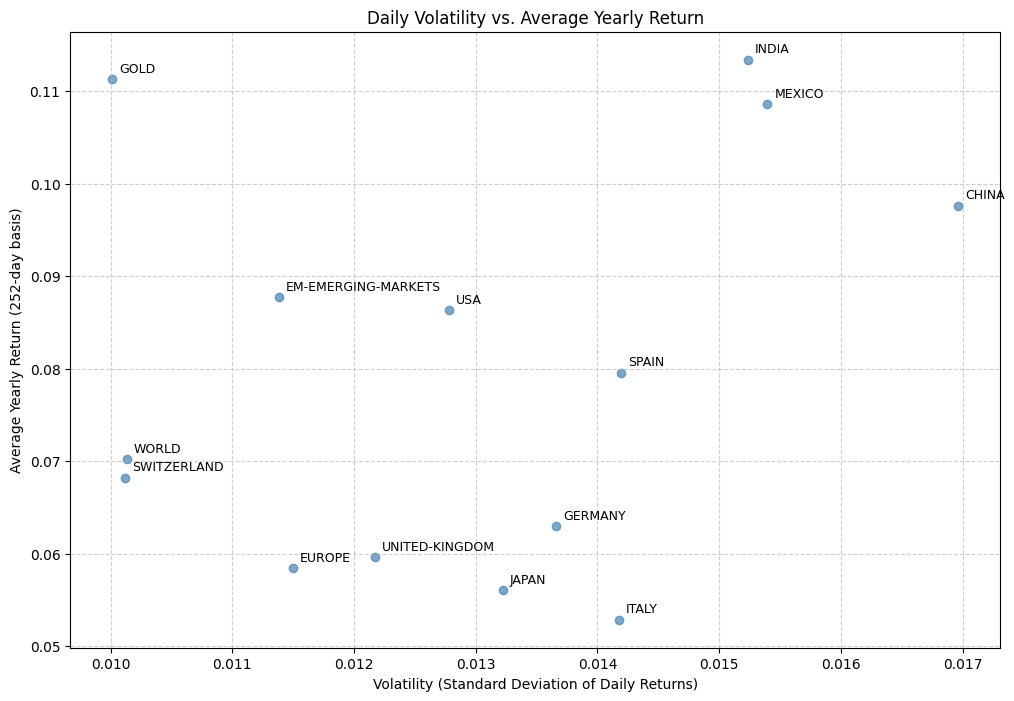

,Yearly Return,Daily Volatility
WORLD,0.070191,0.010134
USA,0.086350,0.012777
GERMANY,0.063002,0.013659
ITALY,0.052862,0.014179
SWITZERLAND,0.068222,0.010118
UNITED-KINGDOM,0.059622,0.012170
JAPAN,0.056053,0.013225
SPAIN,0.079576,0.014191
EUROPE,0.058458,0.011497
EM-EMERGING-MARKETS,0.087717,0.011381


In [29]:
import matplotlib.pyplot as plt

# Calculate daily percentage returns
returns_df = merged_df.pct_change()

# Calculate mean return and volatility (std dev)
# We annualize the return by multiplying by 252 (trading days)
stats = pd.DataFrame({
    'Yearly Return': returns_df.mean() * 252,
    'Daily Volatility': returns_df.std()
})

# Create the scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(stats['Daily Volatility'], stats['Yearly Return'], alpha=0.7, color='steelblue')

# Add labels for each point
for i, txt in enumerate(stats.index):
    plt.annotate(txt, (stats['Daily Volatility'].iloc[i], stats['Yearly Return'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Daily Volatility vs. Average Yearly Return')
plt.xlabel('Volatility (Standard Deviation of Daily Returns)')
plt.ylabel('Average Yearly Return (252-day basis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(stats)

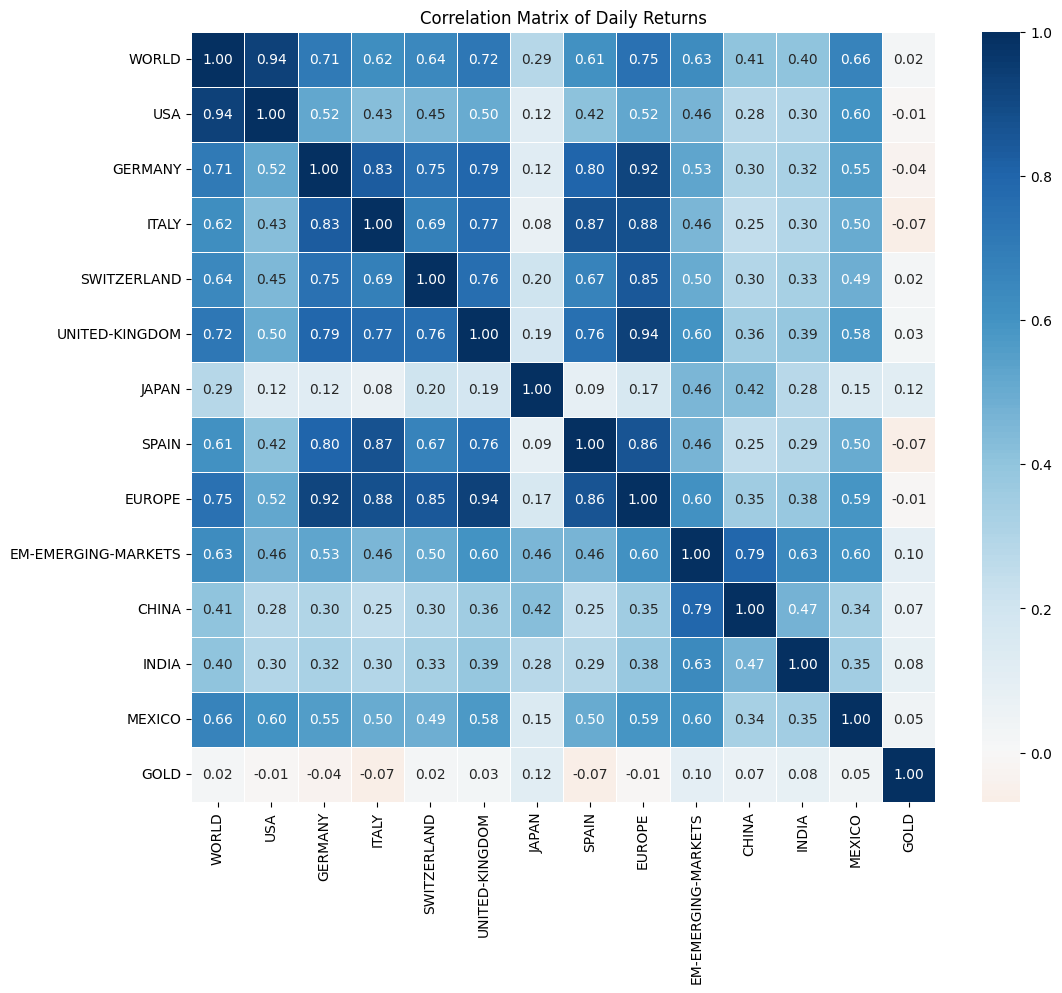

In [30]:
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = returns_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Daily Returns')
plt.show()

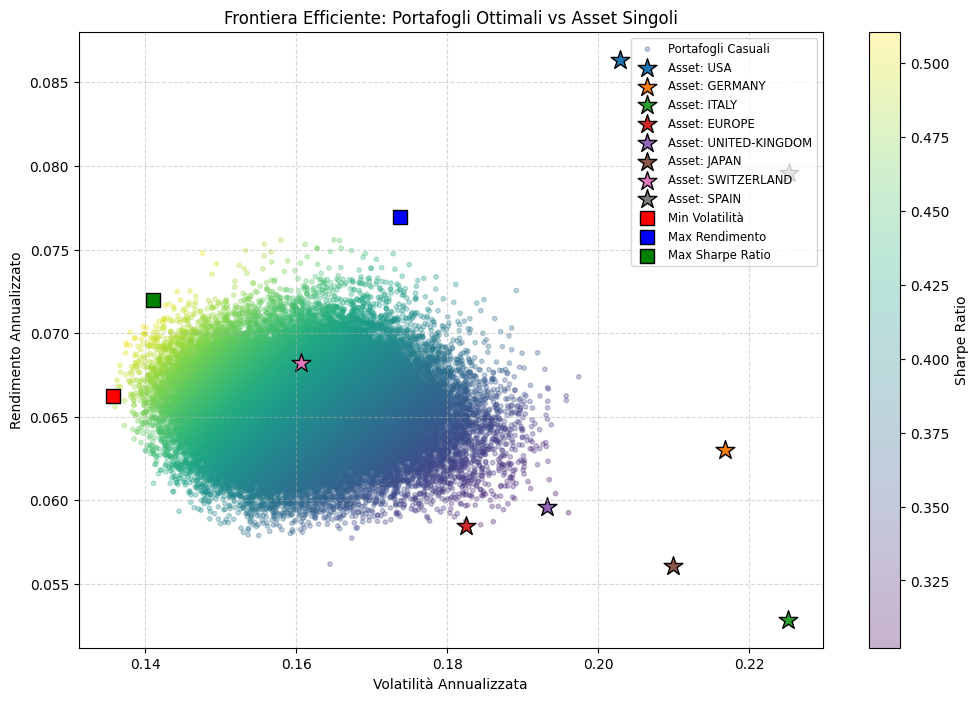

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Asset selezionati
assets = ['USA', 'GERMANY', 'ITALY', 'EUROPE', 'UNITED-KINGDOM','JAPAN','SWITZERLAND','SPAIN']
subset_returns = returns_df[assets].dropna()

# Parametri annualizzati
mean_returns = subset_returns.mean() * 252
cov_matrix = subset_returns.cov() * 252

num_portfolios = 50000
results = np.zeros((3, num_portfolios))
weights_record = []

# Simulazione Monte Carlo
np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = results[0,i] / results[1,i]

# Identificazione portafogli ottimali
min_vol_idx = np.argmin(results[1,:])
max_ret_idx = np.argmax(results[0,:])
max_sharpe_idx = np.argmax(results[2,:])

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3, label='Portafogli Casuali')
plt.colorbar(label='Sharpe Ratio')

for asset in assets:
    vol = subset_returns[asset].std() * np.sqrt(252)
    ret = mean_returns[asset]
    plt.scatter(vol, ret, marker='*', s=200, edgecolors='black', label=f'Asset: {asset}')

plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx], color='red', marker='s', s=100, edgecolors='black', label='Min Volatilità')
plt.scatter(results[1, max_ret_idx], results[0, max_ret_idx], color='blue', marker='s', s=100, edgecolors='black', label='Max Rendimento')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], color='green', marker='s', s=100, edgecolors='black', label='Max Sharpe Ratio')

plt.title('Frontiera Efficiente: Portafogli Ottimali vs Asset Singoli')
plt.xlabel('Volatilità Annualizzata')
plt.ylabel('Rendimento Annualizzato')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [37]:
import pandas as pd

summary_stats = pd.DataFrame({
    'Asset': assets,
    'Min Volatilità': [f"{weights_record[min_vol_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Rendimento': [f"{weights_record[max_ret_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Sharpe Ratio': [f"{weights_record[max_sharpe_idx][i]*100:.2f}%" for i in range(len(assets))]
})

metrics = pd.DataFrame([
    ['---', '---', '---', '---'],
    ['Rendimento Ann.', f"{results[0, min_vol_idx]:.2%}", f"{results[0, max_ret_idx]:.2%}", f"{results[0, max_sharpe_idx]:.2%}"],
    ['Volatilità Ann.', f"{results[1, min_vol_idx]:.2%}", f"{results[1, max_ret_idx]:.2%}", f"{results[1, max_sharpe_idx]:.2%}"],
    ['Sharpe Ratio', f"{results[2, min_vol_idx]:.2f}", f"{results[2, max_ret_idx]:.2f}", f"{results[2, max_sharpe_idx]:.2f}"]
], columns=['Asset', 'Min Volatilità', 'Max Rendimento', 'Max Sharpe Ratio'])

final_summary = pd.concat([summary_stats, metrics], ignore_index=True)
print("Dettagli dei Portafogli Ottimali:")
display(final_summary)

Dettagli dei Portafogli Ottimali:


,Asset,Min Volatilità,Max Rendimento,Max Sharpe Ratio
0,USA,22.41%,36.59%,25.96%
1,GERMANY,0.83%,2.88%,1.08%
2,ITALY,9.48%,10.54%,3.52%
3,EUROPE,10.22%,0.92%,0.29%
4,UNITED-KINGDOM,0.54%,2.80%,0.35%
5,JAPAN,29.16%,1.42%,24.61%
6,SWITZERLAND,27.12%,6.40%,20.37%
7,SPAIN,0.24%,38.43%,23.82%
8,---,---,---,---
9,Rendimento Ann.,6.62%,7.69%,7.20%


In [32]:
url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/"

elenco = {  "WORLD":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
            "WORLD SMALL CAPS":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/SMALL-CAP/WORLD-SMALL-CAP.csv",
            "GOLD":"EUR/EXTRA/GOLD.csv"
}

In [33]:
file_bonds = "https://www.paolocoletti.com/wp-content/uploads/youtube/tassi_btp_eurobond.xlsx"
# ESTER is in sheet "ESTER", 11th column Date, 12th column ESTER price (not rate), first row contains headers
# GOV BONDS is in sheet "Eurozone", 1st column Date, 6th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# short GOV BONDS is in sheet "Eurozone", 1st column Date, 2nd column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# long GOV BONDS is in sheet "Eurozone", 1st column Date, 5th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# EURIBOR are in sheet "Euribor", column 1 is date with header, columns 2-3-4-5 are euribor 1M 3M 6M 12M, these are prices and not rates.